Import all globally needed libraries for the project.

In [49]:
# Data Analysis
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Required
from datetime import datetime

Read the raw data of the hand sign read by the camera.

In [73]:
df = pd.read_csv('data/combined_data_raw.csv')
df.head(5)

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
0,-0.083243,0.026819,-0.033383,-0.196480,-0.058573,-0.046677,-0.254192,-0.167540,-0.060237,-0.265515,...,-0.032516,-0.025951,-0.324772,-0.079050,-0.001808,-0.236136,-0.071494,0.014113,-0.175870,-0.052260
1,-0.083243,0.026819,-0.033383,-0.196480,-0.058573,-0.046677,-0.254192,-0.167540,-0.060237,-0.265515,...,-0.032516,-0.025951,-0.324772,-0.079050,-0.001808,-0.236136,-0.071494,0.014113,-0.175870,-0.052260
2,-0.104840,-0.024300,-0.031908,-0.210515,-0.158841,-0.040106,-0.259754,-0.285863,-0.051011,-0.270876,...,-0.031842,-0.019223,-0.360048,-0.057665,-0.023667,-0.275401,-0.037595,-0.014373,-0.231941,-0.012997
3,-0.079142,-0.002783,-0.037881,-0.173042,-0.136976,-0.044528,-0.216039,-0.265142,-0.050389,-0.233696,...,-0.029699,0.003093,-0.311050,-0.057351,-0.005008,-0.219439,-0.037542,0.003300,-0.190854,-0.013664
4,-0.079142,-0.002783,-0.037881,-0.173042,-0.136976,-0.044528,-0.216039,-0.265142,-0.050389,-0.233696,...,-0.029699,0.003093,-0.311050,-0.057351,-0.005008,-0.219439,-0.037542,0.003300,-0.190854,-0.013664


Plot the data.

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

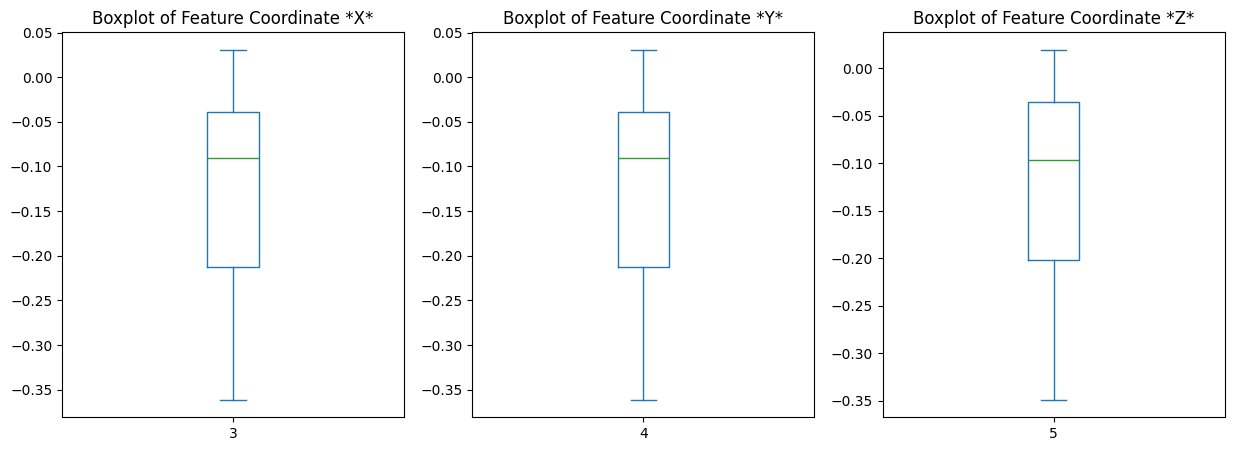

In [72]:
#lot_df = df.drop('label', axis=1)

fig = plt.figure(figsize=(15, 5))

ax0 = fig.add_subplot(1, 3, 1)
ax1 = fig.add_subplot(1, 3, 2)
ax2 = fig.add_subplot(1, 3, 3)

df.iloc[3].plot(kind='box', ax=ax0)
ax0.set_title('Boxplot of Feature Coordinate *X*')

df.iloc[4].plot(kind='box', ax=ax1)
ax1.set_title('Boxplot of Feature Coordinate *Y*')

df.iloc[5].plot(kind='box', ax=ax2)
ax2.set_title('Boxplot of Feature Coordinate *Z*')

#plt.boxplot() # Every (21 landmark % 3) - 1 is a z feature variable.
plt.show()

As we can see the most column that has outliers are Z coordinates. This is due to the difficulties of finding a *Z* coordinate from a 2D images. So because of this we really need to clean up the Z coordinates. We could even just delete the *Z* coordinate all together. So lets try to conclude this. We'll have one model with the Z feature variable and the other without.

We will need to clean up every column data of this dataframe. For the data X and Y we can be a litle strict du to its consistent data collector. But, due to Z's fluctuative data we need to be leaner for this.

In [63]:
import os
dir_list = os.listdir('data')

main_df = pd.DataFrame()
raw_df = pd.DataFrame()

for i in dir_list:
    if i in ['combined_data.csv', 'combined_data_raw.csv']:
        continue
    _data = pd.read_csv(os.path.join('data', i))
    df_temp = _data
    raw_df_temp = _data
    
    ## Remove outliers
    df_temp = df_temp.dropna() # Drop rows with NaN values
    for column in df_temp.columns:
        if column != 'label':
            Q1 = df_temp[column].quantile(0.05)
            Q3 = df_temp[column].quantile(0.95)
            IQR = Q3 - Q1
            threshold = 1.5
            outliers = df_temp[(df_temp[column] < (Q1 - threshold * IQR)) | (df_temp[column] > (Q3 + threshold * IQR))]
            df_temp = df_temp.drop(outliers.index)
    
    df_temp['label'] = i[0] # Assuming folder name is single character label
    print(f'File: {i}, Shape: {df_temp.shape}')
    raw_df = pd.concat([raw_df, raw_df_temp], ignore_index=True)
    main_df = pd.concat([main_df, df_temp], ignore_index=True)

raw_df.to_csv('data/combined_data_raw.csv', index=False)
main_df.to_csv('data/combined_data.csv', index=False)
main_df.shape

File: a_data_raw.csv, Shape: (300, 61)
File: b_data_raw.csv, Shape: (300, 61)
File: c_data_raw.csv, Shape: (300, 61)
File: d_data_raw.csv, Shape: (300, 61)
File: e_data_raw.csv, Shape: (298, 61)
File: f_data_raw.csv, Shape: (300, 61)
File: i_data_raw.csv, Shape: (299, 61)
File: l_data_raw.csv, Shape: (298, 61)


(2395, 61)

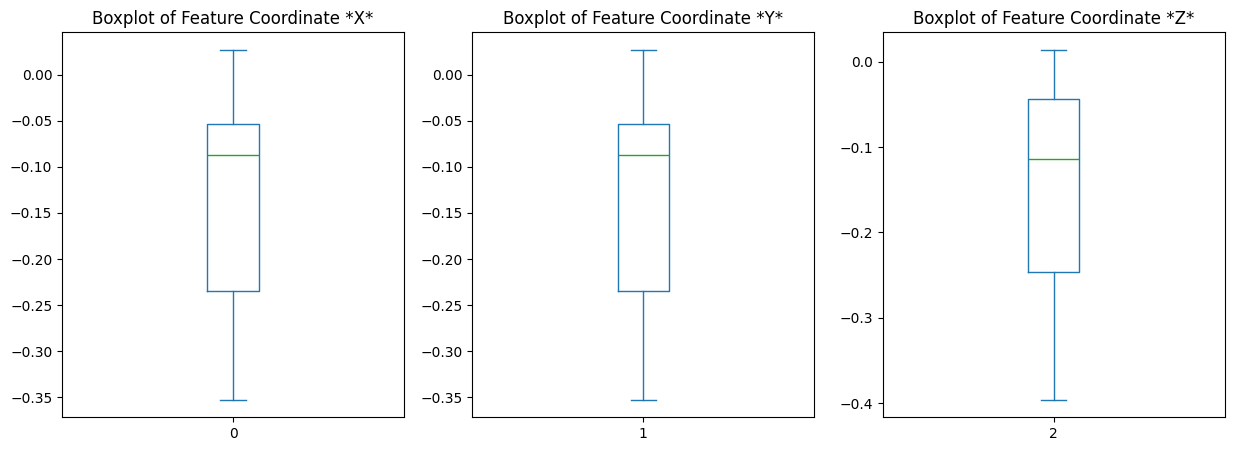

In [69]:
plot_df = main_df.drop('label', axis=1)

fig = plt.figure(figsize=(15, 5))

ax0 = fig.add_subplot(1, 3, 1)
ax1 = fig.add_subplot(1, 3, 2)
ax2 = fig.add_subplot(1, 3, 3)

plot_df.iloc[0].plot(kind='box', ax=ax0)
ax0.set_title('Boxplot of Feature Coordinate *X*')

plot_df.iloc[1].plot(kind='box', ax=ax1)
ax1.set_title('Boxplot of Feature Coordinate *Y*')

plot_df.iloc[2].plot(kind='box', ax=ax2)
ax2.set_title('Boxplot of Feature Coordinate *Z*')

#plt.boxplot() # Every (21 landmark % 3) - 1 is a z feature variable.
plt.show()

Combine all the cleaned up data to *one* big csv corpus. Next we will split the data to Train, Test and Validate. After, we'll standardize the data using the scaler element that we'd mde earlier. The *main.df['label']* will get the categorical labels or the target of the data that should be recognize.

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    main_df.drop('label', axis=1), main_df['label'], test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

We will save the scaler to apply it for the input data later.

In [ ]:
from joblib import dump as jldump

jldump(scaler, os.join('model', f'svc_scaler_{(str(datetime.now().date())).replace("-", "")}.pkl'))

['svc_scaler_20250928.pkl']

Now we will make the machine learning (*ML*). There are a lot of machine learning model that can be our candidate. Some of them are Logical Regression and Tree-based. In here we will use Logical Reasoning due to Tree-based has troubles using high dimensional feature variable.

In [57]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train)

print(f'Here is the accuracy of LR for train set: {logreg.score(X_train_scaled, y_train)}')
print(f'Here is the accuracy of LR for test set: {logreg.score(X_test_scaled, y_test)}')


Here is the accuracy of LR for train set: 1.0
Here is the accuracy of LR for test set: 1.0


Searching for the best model parameter with GridSearchCV

In [74]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear']
}

In [75]:
from sklearn.svm import SVC

svc = SVC()

# cv=5 means 5-fold cross-validation
# verbose=3 displays a detailed log of the process
grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=5,
    verbose=3,
    scoring='accuracy', # The metric to optimize (e.g., 'accuracy', 'f1_weighted')
    n_jobs=-1           # Use all available CPU cores for speed
)

# NOTE: This trains the C * gamma * kernel
print("Starting GridSearchCV...")
grid_search.fit(X_train_scaled, y_train)
print("GridSearchCV finished.")

Starting GridSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
GridSearchCV finished.


In [ ]:
print("Best parameters found on the training set:", grid_search.best_params_)
print("Best cross-validation score (accuracy):", grid_search.best_score_)

# Get the best model with the best parameter
model = grid_search.best_estimator_

print(f'Here is the accuracy of SVC for train set: {model.score(X_train_scaled, y_train)}')
print(f'Here is the accuracy of SVC for test set: {model.score(X_test_scaled, y_test)}')

# The complete results of all parameter combinations
results = pd.DataFrame(grid_search.cv_results_)
print("\nFull Search Results:")
print(results[['param_C', 'param_gamma', 'param_kernel', 'mean_test_score', 'rank_test_score']])

Best parameters found on the training set: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score (accuracy): 1.0
Here is the accuracy of SVC for train set: 1.0
Here is the accuracy of SVC for test set: 1.0

Full Search Results:
    param_C  param_gamma param_kernel  mean_test_score  rank_test_score
0      0.01         0.01          rbf         0.690168               12
1      0.01         0.10          rbf         0.221382               19
2      0.01         1.00          rbf         0.145440               21
3      0.01        10.00          rbf         0.130923               22
4      0.01       100.00          rbf         0.130923               22
5      0.10         0.01          rbf         0.978445                8
6      0.10         0.10          rbf         0.984913                7
7      0.10         1.00          rbf         0.197179               20
8      0.10        10.00          rbf         0.130923               22
9      0.10       100.00          rbf 

In [61]:
from sklearn.metrics import classification_report

# Use the best model found by the grid search to predict on the test set
y_pred = model.predict(X_test_scaled)

# Final evaluation report
print("\nFinal Model Evaluation on Test Data:")
# Remember to use the LabelEncoder to get the original class names if possible
# target_names=le.classes_ if you still have 'le' object from the tutorial
print(classification_report(y_test, y_pred))


Final Model Evaluation on Test Data:
              precision    recall  f1-score   support

           a       1.00      1.00      1.00        58
           b       1.00      1.00      1.00        69
           c       1.00      1.00      1.00        48
           d       1.00      1.00      1.00        54
           e       1.00      1.00      1.00        58
           f       1.00      1.00      1.00        59
           i       1.00      1.00      1.00        62
           l       1.00      1.00      1.00        57

    accuracy                           1.00       465
   macro avg       1.00      1.00      1.00       465
weighted avg       1.00      1.00      1.00       465



In [ ]:
jldump(model, os.join('model', f'svc_model_{(str(datetime.now().date())).replace("-", "")}.pkl'))

['svc_model_20250928.pkl']